# Capítulo 6: Determinantes

---

### 6.1.

---

### 6.2.

In [ ]:
# Ejercicio 1
import numpy as np

def determinante_2x2(matriz):
    """
    Calcula el determinante de una matriz 2x2.
    Parámetros:
    matriz (list): Lista de listas representando la matriz 2x2.
    Retorna:
    float: Determinante de la matriz.
    """
    if len(matriz) != 2 or len(matriz[0]) != 2 or len(matriz[1]) != 2:
        raise ValueError("La matriz debe ser 2x2")
    return matriz[0][0] * matriz[1][1] - matriz[0][1] * matriz[1][0]

# Ejemplo
matriz_2x2 = [[1, 8], [4, 7]]
print(f"Determinante de la matriz 2x2: {determinante_2x2(matriz_2x2)}")

Determinante de la matriz 2x2: -25


In [ ]:
# Ejercicio 2
def determinante_3x3(matriz):
    """
    Calcula el determinante de una matriz 3x3 usando la Regla de Sarrus.
    Parámetros:
    matriz (list): Lista de listas representando la matriz 3x3.
    Retorna:
    float: Determinante de la matriz.
    """
    if len(matriz) != 3 or any(len(row) != 3 for row in matriz):
        raise ValueError("La matriz debe ser 3x3") 
    a, b, c = matriz[0]
    d, e, f = matriz[1]
    g, h, i = matriz[2]
    return a*e*i + b*f*g + c*d*h - c*e*g - b*d*i - a*f*h

# Ejemplo
matriz_3x3 = [[4, 1, 2], [2, 4, 7], [1, 1, 7]]
print(f"Determinante de la matriz 3x3: {determinante_3x3(matriz_3x3)}")

Determinante de la matriz 3x3: 73


In [ ]:
# Ejercicio 3
def cofactor(matriz, fila, columna):
    """
    Calcula el cofactor de un elemento en una matriz.
    Parámetros:
    matriz (list): Lista de listas representando la matriz.
    fila (int): Índice de la fila del elemento.
    columna (int): Índice de la columna del elemento.
    Retorna:
    float: Cofactor del elemento.
    """
    menor = [fila[:columna] + fila[columna+1:] for fila in (matriz[:fila] + matriz[fila+1:])]
    return (-1) ** (fila + columna) * determinante(menor)

def determinante(matriz):
    """
    Calcula el determinante de una matriz cuadrada usando la expansión por cofactores.
    Parámetros:
    matriz (list): Lista de listas representando la matriz.

    Retorna:
    float: Determinante de la matriz.
    """
    n = len(matriz)
    if n == 2:
        return determinante_2x2(matriz)
    det = 0
    for c in range(n):
        det += matriz[0][c] * cofactor(matriz, 0, c)
    return det

# Ejemplo
matriz_4x4 = [
    [1, 2, 3, 4],
    [2, 5, 4, 5],
    [3, 1, 7, 6],
    [4, 1, 2, 1]
]

print(f"Determinante de la matriz 4x4: {determinante(matriz_4x4)}")

Determinante de la matriz 4x4: -72


### 6.3.

---

### 6.4.

Volumen del paralelepípedo: 9.51619735392994e-16


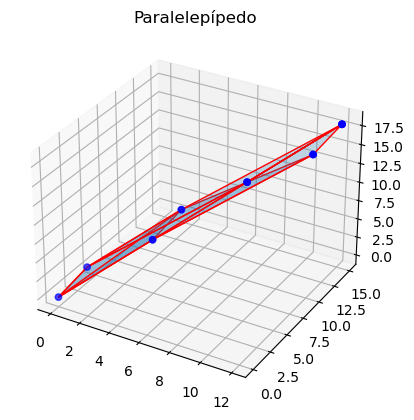

In [ ]:
# Ejercicio 4
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def volumen_paralelepipedo(v1, v2, v3):
    A = np.array([v1, v2, v3])
    return np.abs(np.linalg.det(A))

def graficar_paralelepipedo(v1, v2, v3):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Vértices del paralelepípedo
    p0 = np.array([0, 0, 0])
    p1 = np.array(v1)
    p2 = np.array(v2)
    p3 = np.array(v3)
    p4 = p1 + p2
    p5 = p2 + p3
    p6 = p3 + p1
    p7 = p1 + p2 + p3
    vertices = np.array([p0, p1, p4, p2, p0, p2, p5, p4, p0, p1, p6, p7, p1, p4, p7, p6, p2, p5, p7, p6])
    faces = [[vertices[j] for j in range(i, i + 4)] for i in range(0, 20, 4)]
    ax.add_collection3d(Poly3DCollection(faces, alpha=.25, linewidths=1, edgecolors='r'))
    ax.scatter(*vertices.T, color='b')
    plt.title("Paralelepípedo")
    plt.show()

# Vectores que definen el paralelepípedo
v1 = [1, 2, 3]
v2 = [4, 5, 6]
v3 = [7, 8, 9]
volumen = volumen_paralelepipedo(v1, v2, v3)

print(f"Volumen del paralelepípedo: {volumen}")
graficar_paralelepipedo(v1, v2, v3)

Área del polígono: 10.5


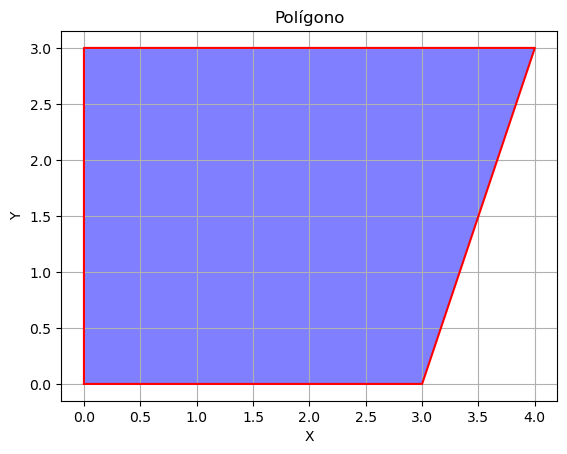

In [ ]:
# Ejercicio 5
import matplotlib.pyplot as plt
def area_poligono(vertices):
    n = len(vertices)
    area = 0
    for i in range(n):
        x1, y1 = vertices[i]
        x2, y2 = vertices[(i + 1) % n]
        area += x1 * y2 - y1 * x2
    return 0.5 * abs(area)

def graficar_poligono(vertices):
    vertices.append(vertices[0])  # Cerrar el polígono
    x, y = zip(*vertices)
    plt.fill(x, y, 'b', alpha=0.5)
    plt.plot(x, y, 'r')
    plt.title("Polígono")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

# Coordenadas de los vértices del polígono
vertices = [(0, 0), (3, 0), (4, 3), (0, 3)]
area = area_poligono(vertices)

print(f"Área del polígono: {area}")
graficar_poligono(vertices)

Polinomio característico: [ 1.00000000e+00  1.11022302e-16 -6.00000000e+00 -4.00000000e+00]


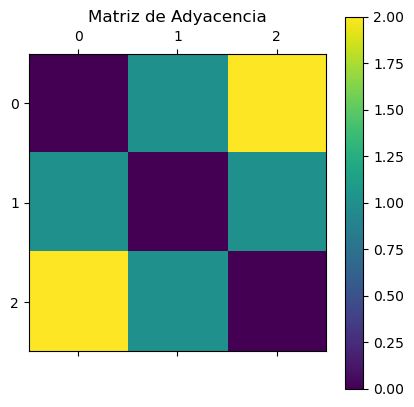

In [ ]:
# Ejercicio 6
import numpy as np
import matplotlib.pyplot as plt

def polinomio_caracteristico(A):
    coef = np.poly(A)
    return coef

def graficar_matriz(A):
    plt.matshow(A, cmap='viridis')
    plt.colorbar()
    plt.title("Matriz de Adyacencia")
    plt.show()

# Matriz de adyacencia del grafo
A = np.array([
    [0, 1, 2],
    [1, 0, 1],
    [2, 1, 0]
])
polinomio = polinomio_caracteristico(A)

print(f"Polinomio característico: {polinomio}")
graficar_matriz(A)

Número de árboles generadores: 4


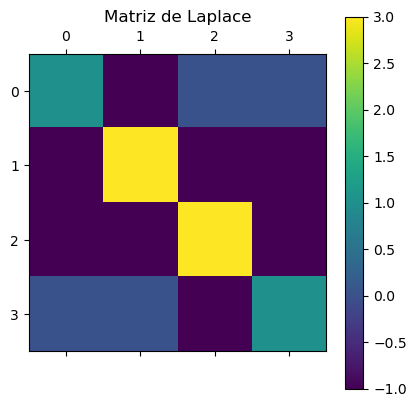

In [ ]:
# Ejercicio 7
import numpy as np
import matplotlib.pyplot as plt

def numero_arboles_generadores(L):
    L_cofactor = np.delete(np.delete(L, 0, axis=0), 0, axis=1)
    return np.linalg.det(L_cofactor)

def graficar_matriz(L):
    plt.matshow(L, cmap='viridis')
    plt.colorbar()
    plt.title("Matriz de Laplace")
    plt.show()

# Matriz de adyacencia del grafo
A = np.array([
    [0, 1, 0, 0],
    [1, 0, 1, 1],
    [1, 1, 0, 1],
    [0, 0, 1, 0]
])

# Matriz de grados (D)
D = np.diag(np.sum(A, axis=1))

# Matriz de Laplace (L = D - A)
L = D - A
numero_arboles = numero_arboles_generadores(L)

print(f"Número de árboles generadores: {int(numero_arboles)}")
graficar_matriz(L)

### 6.5.

In [ ]:
# Ejercicio 8
import numpy as np
from scipy.linalg import lu, det

# Definir una matriz de ejemplo
A = np.array([[1, 2, 3],
              [7, 5, 7],
              [7, 8, 1]])

# Método de la Expansión por Cofactores (no recomendado para matrices grandes)
def cofactor_expansion(matrix):
    n = matrix.shape[0]
    if n == 1:
        return matrix[0, 0]
    determinant = 0
    for col in range(n):
        submatrix = np.delete(np.delete(matrix, 0, axis=0), col, axis=1)
        sign = (-1) ** col
        determinant += sign * matrix[0, col] * cofactor_expansion(submatrix)
    return determinant

# Método de Gauss-Jordan usando la función de SciPy
def gauss_jordan(matrix):
    _, u = lu(matrix, permute_l=True)
    return np.prod(np.diag(u))

# Descomposición LU
def lu_decomposition(matrix):
    p, l, u = lu(matrix)
    return det(l) * det(u)

# Método de Cholesky (aplicable solo a matrices simétricas y definidas positivas)
def cholesky_decomposition(matrix):
    l = np.linalg.cholesky(matrix)
    return np.prod(np.diag(l)) ** 2

# Método de Descomposición de Schur
def schur_decomposition(matrix):
    T, _ = np.linalg.schur(matrix)
    return np.prod(np.diag(T))

# Cálculo de determinantes usando diferentes métodos
det_cofactor = cofactor_expansion(A)
det_gauss_jordan = gauss_jordan(A)
det_lu = lu_decomposition(A)

print(f"Determinante por expansión de cofactores: {det_cofactor}")
print(f"Determinante por Gauss-Jordan: {det_gauss_jordan}")
print(f"Determinante por descomposición LU: {det_lu}")

# Cálculo del determinante usando NumPy directamente
det_numpy = np.linalg.det(A)

print(f"Determinante usando NumPy: {det_numpy}")

Determinante por expansión de cofactores: 96
Determinante por Gauss-Jordan: 96.0
Determinante por descomposición LU: 96.0
Determinante usando NumPy: 95.99999999999999


### FIN